## ⚙️ Loading Required Libraries

In [2]:
import yfinance as yf
import pandas as pd

print("Libraries loaded successfully")

Libraries loaded successfully


# 📈 NIFTY 50 Stock Market Analysis

Analyzing selected NIFTY 50 stocks using Python, statistical techniques, and financial metrics to evaluate performance, risk, and investment insights.

In [4]:
stocks = ["RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS"]

data = yf.download( stocks, start="2023-01-01", end="2025-01-01")

data.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                      \
Ticker     HDFCBANK.NS ICICIBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS   
Date                                                                         
2023-01-02  783.677856   880.647339  1397.702148  1170.478027  2893.560303   
2023-01-03  788.802368   879.573914  1396.372437  1161.912598  2937.831543   
2023-01-04  774.704163   877.378235  1370.921875  1144.418213  2940.758789   
2023-01-05  769.724060   857.910278  1352.946289  1142.373413  2937.609863   
2023-01-06  767.173889   849.078918  1328.459106  1152.756348  2849.288574   

Price             High                                                      \
Ticker     HDFCBANK.NS ICICIBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS   
Date                                                                         
2023-01-02  788.994783   885.087402  1399.994967  1171.886668  2898.351316   
2023-01-03  790.558642   884.062816  1405.635401  1169.160249  2945.505741   
2023-01-04  791.881828   885.965680  1394.950564  1163.730055  2952.026408   
2023-01-05  778.553536   881.184053  1381.102167  1152.529209  2960.854475   
2023-01-06  774.247032   857.715144  1352.762984  1157.777455  2929.136613   

Price       ...        Open                                         \
Ticker      ... HDFCBANK.NS ICICIBANK.NS      INFY.NS  RELIANCE.NS   
Date        ...                                                      
2023-01-02  ...  782.859895   872.401474  1388.530874  1158.709143   
2023-01-03  ...  780.550329   876.792792  1393.896125  1165.547781   
2023-01-04  ...  786.709275   877.280675  1394.950564  1161.889687   
2023-01-05  ...  777.085950   879.134811  1381.102167  1146.667484   
2023-01-06  ...  770.830752   857.715144  1348.177347  1148.098818   

Price                        Volume                                             
Ticker           TCS.NS HDFCBANK.NS ICICIBANK.NS  INFY.NS RELIANCE.NS   TCS.NS  
Date                                                                            
2023-01-02  2893.161106     4381378      4315403  3801140     5316175   709547  
2023-01-03  2885.176105     8378030      5846855  4551130     7658932  1245178  
2023-01-04  2933.705589    10351600     12454582  7059590     9264891  1231668  
2023-01-05  2954.555264    10941436     16547196  9868404    13637099  1826057  
2023-01-06  2927.761409     9092462     14804613  6443714     6349597  2488376  

[5 rows x 25 columns]

## 🧹 Data Preprocessing

✔️ Checked for missing values
✔️ Removed null observations
✔️ Verified data consistency before analysis

In [5]:
print(data.isnull().sum())

data = data.dropna()

Price   Ticker      
Close   HDFCBANK.NS     0
        ICICIBANK.NS    0
        INFY.NS         0
        RELIANCE.NS     0
        TCS.NS          0
High    HDFCBANK.NS     0
        ICICIBANK.NS    0
        INFY.NS         0
        RELIANCE.NS     0
        TCS.NS          0
Low     HDFCBANK.NS     0
        ICICIBANK.NS    0
        INFY.NS         0
        RELIANCE.NS     0
        TCS.NS          0
Open    HDFCBANK.NS     0
        ICICIBANK.NS    0
        INFY.NS         0
        RELIANCE.NS     0
        TCS.NS          0
Volume  HDFCBANK.NS     0
        ICICIBANK.NS    0
        INFY.NS         0
        RELIANCE.NS     0
        TCS.NS          0
dtype: int64


## 📊 Extracting Closing Prices 💹

The downloaded dataset contains multiple stock attributes, including **Open**, **High**, **Low**, **Close**, **Adjusted Close**, and **Volume**.
For this analysis, we focus only on the **Closing Price** , as it represents the final trading price of a stock at the end of each trading day. Closing prices are widely used in financial analysis to compute returns , assess performance , and evaluate risk .
The code below extracts the **Close** price data for all selected stocks from the dataset.

In [6]:
close_prices = data["Close"]

close_prices.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2023-01-02,783.677856,880.647339,1397.702148,1170.478027,2893.560303
2023-01-03,788.802368,879.573914,1396.372437,1161.912598,2937.831543
2023-01-04,774.704163,877.378235,1370.921875,1144.418213,2940.758789
2023-01-05,769.724060,857.910278,1352.946289,1142.373413,2937.609863
2023-01-06,767.173889,849.078918,1328.459106,1152.756348,2849.288574


## 📈 Calculating Daily Returns 💹
Stock prices alone do not provide a complete picture of performance because different stocks trade at different price levels. To compare stocks fairly, **daily returns** 📊 are calculated using the percentage change in closing prices from one trading day to the next 🔄.

### 🧮 Formula
Daily Return = (Current Closing Price − Previous Closing Price) ÷ Previous Closing Price

Daily returns are essential for:
- 📊 Measuring stock performance over time  
- ⚖️ Comparing different stocks on a common scale  
- 📉 Calculating risk and volatility  
- 🔗 Performing correlation and Sharpe Ratio analysis  

The following code computes the **daily percentage returns** 🧾 for all selected stocks.

In [7]:
returns = close_prices.pct_change()

returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2023-01-02,NaN,NaN,NaN,NaN,NaN
2023-01-03,0.006539,-0.001219,-0.000951,-0.007318,0.015300
2023-01-04,-0.017873,-0.002496,-0.018226,-0.015057,0.000996
2023-01-05,-0.006428,-0.022189,-0.013112,-0.001787,-0.001071
2023-01-06,-0.003313,-0.010294,-0.018099,0.009089,-0.030066


## 📊 Interpretation of Daily Returns 💹

Each value shows the **percentage change** in a stock’s closing price compared to the previous trading day.

- 📈 **Positive values** → Stock price increased  
- 📉 **Negative values** → Stock price decreased  
- ⚡ Larger absolute values → Higher price movement & volatility  

### 🔍 Key Observations

- ❌ First row shows **NaN** since there is no previous day for comparison  
- 📈 On **03-Jan-2023**, TCS gained ~**1.53%**  
- 📉 On **04-Jan-2023**, Infosys and Reliance showed negative returns  
- 🔄 Returns fluctuate due to market sentiment, news, and economic factors  

These returns will be used for **risk analysis, performance comparison, and diversification insights** in later sections.

## 📊 Calculating Total Return 💹

While **daily returns** 📉 capture short-term price movements, investors often focus on the **overall performance** of a stock across the full analysis period 📅.  
**Total Return** 📈 measures the percentage gain or loss from the start to the end of the investment period.
### 🧮 Formula

Total Return (%) = ((Final Price ÷ Initial Price) − 1) × 100
This helps answer:  
> 💬 *“If I had invested at the beginning of the period, how much would my investment have grown by the end?”*
### 📌 Insight
- 📈 Higher total return → Stronger overall performance  
- 📉 Lower/negative return → Weak or declining performance  
This metric provides a **long-term perspective on investment growth** 💰 over the selected timeframe.

In [8]:
total_return = ((close_prices.iloc[-1] / close_prices.iloc[0]) - 1) * 100
total_return

Ticker
HDFCBANK.NS     11.602366
ICICIBANK.NS    44.420629
INFY.NS         30.640265
RELIANCE.NS      2.953083
TCS.NS          32.518693
dtype: float64

### 📊 Result Summary 💹

Between **January 2023 and January 2025** 📅:

- 🏆 **ICICI Bank** delivered the highest total return: **44.42%** 📈  
- 📉 **Reliance** showed the lowest growth: **2.95%**  

### 🔍 Insight

- 💰 ICICI Bank significantly outperformed other NIFTY 50 stocks  
- ⚖️ Reliance delivered relatively flat long-term performance compared to peers  

## 📊 Visualizing Total Returns
A horizontal bar chart is used to display the total returns of the selected NIFTY 50 stocks over the analysis period.

### Why This Visualization?
- 📈 Quickly identifies the best-performing stock
- 📉 Highlights underperforming stocks
- 🔍 Makes comparisons easier than reading raw numbers
- 📊 Provides a clear ranking of stock performance

The stocks are sorted in ascending order of total return, allowing for easy interpretation of relative performance.

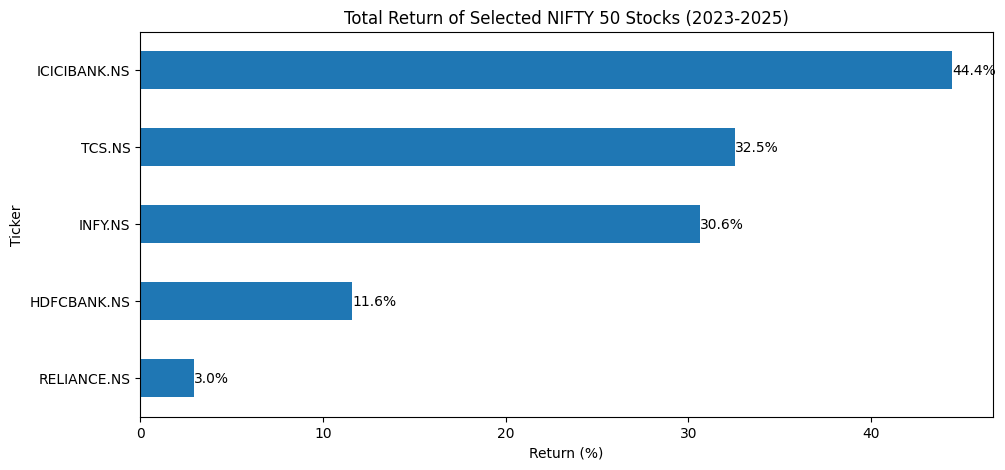

In [9]:
import matplotlib.pyplot as plt
ax = total_return.sort_values().plot(
    kind="barh",
    figsize=(11,5)
)

plt.title("Total Return of Selected NIFTY 50 Stocks (2023-2025)")
plt.xlabel("Return (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### 💡 Key Insight

Based on total returns alone, **ICICI Bank was the strongest performer**. However, investment decisions should also consider risk, which will be analyzed in the next section.

## ⚠️ Risk Analysis
Risk is measured using the standard deviation of daily returns.
A higher value indicates greater price fluctuations and therefore higher investment risk, while a lower value suggests more stable performance.
The following analysis compares the volatility of the selected NIFTY 50 stocks.

In [10]:
risk = returns.std() * 100

print(risk)

Ticker
HDFCBANK.NS     1.247161
ICICIBANK.NS    1.155149
INFY.NS         1.454228
RELIANCE.NS     1.281313
TCS.NS          1.241659
dtype: float64


### 🔍 Interpretation
- Infosys showed the highest risk (**1.45%**), indicating the greatest price volatility.
- ICICI Bank had the lowest risk (**1.16%**), making it the most stable stock among the selected companies.
- HDFC Bank, TCS, and Reliance exhibited similar levels of risk, ranging between **1.24%** and **1.28%**.

### 💡 Key Insight
While ICICI Bank generated the highest return, it also maintained relatively low risk, suggesting strong overall performance.

## 📊 Return vs Risk Comparison
To better evaluate stock performance, returns and risk are combined into a single comparison table.
This allows us to analyze not only how much a stock gained, but also the level of risk taken to achieve those returns.

In [11]:
comparison = pd.DataFrame({
    "Return (%)": total_return,
    "Risk (%)": risk
})

comparison

,Return (%),Risk (%)
Ticker,,
HDFCBANK.NS,11.602366,1.247161
ICICIBANK.NS,44.420629,1.155149
INFY.NS,30.640265,1.454228
RELIANCE.NS,2.953083,1.281313
TCS.NS,32.518693,1.241659


### 🔍 Interpretation
- ICICI Bank delivered the highest return (**44.42%**) while maintaining the lowest risk (**1.16%**).
- Infosys generated strong returns (**30.64%**) but also had the highest risk (**1.45%**).
- TCS provided a good balance between return (**32.52%**) and risk (**1.24%**).
- Reliance recorded the lowest return (**2.95%**) despite having risk levels similar to the other stocks.

### 💡 Key Insight
Among the selected stocks, **ICICI Bank offered the most attractive return-to-risk profile**, making it a strong candidate for further risk-adjusted analysis.

## 📈 Risk vs Return Analysis
A risk-return scatter plot helps visualize the relationship between potential returns and the level of risk associated with each stock.
In general, investors seek stocks that offer **higher returns with lower risk**. This visualization makes it easier to compare investment opportunities and identify stocks with favorable risk-return characteristics.

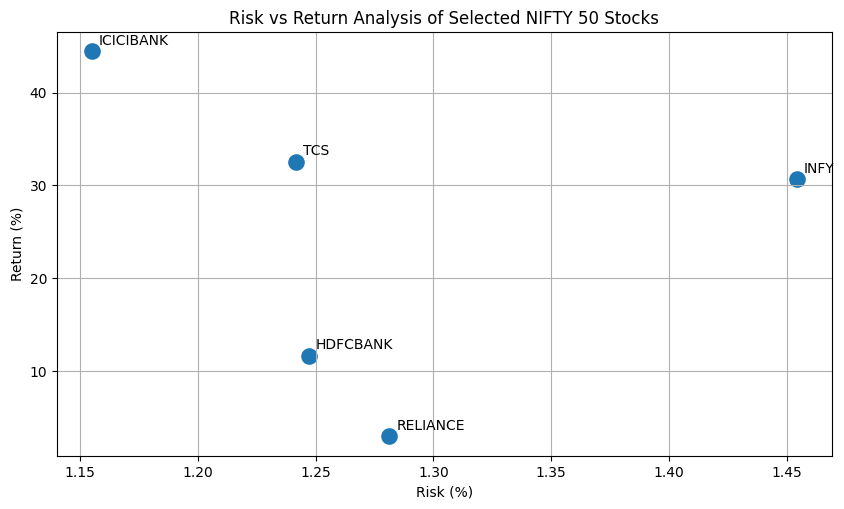

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5.5))

plt.scatter(
    comparison["Risk (%)"],
    comparison["Return (%)"],
    s=120
)

for stock in comparison.index:
    plt.annotate(
        stock.replace(".NS", ""),
        (
            comparison.loc[stock, "Risk (%)"],
            comparison.loc[stock, "Return (%)"]
        ),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("Risk (%)")
plt.ylabel("Return (%)")
plt.title("Risk vs Return Analysis of Selected NIFTY 50 Stocks")

plt.grid(True)

plt.show()

### 💡 Key Insight

The chart suggests that **ICICI Bank provided the most attractive risk-return tradeoff** during the analysis period, while TCS also demonstrated a favorable balance between risk and return.

## 🏆 Risk-Adjusted Return Analysis

Return alone does not provide a complete picture of investment performance. Investors also need to consider the amount of risk taken to achieve those returns.
To evaluate performance more fairly, a risk-adjusted return metric is calculated by dividing total return by risk.

### Formula
Risk-Adjusted Return = Total Return / Risk
A higher value indicates that a stock generated more return for each unit of risk undertaken.

In [13]:
risk_adjusted_return = total_return / risk

print(risk_adjusted_return.sort_values(ascending=False))

Ticker
ICICIBANK.NS    38.454470
TCS.NS          26.189722
INFY.NS         21.069784
HDFCBANK.NS      9.303018
RELIANCE.NS      2.304732
dtype: float64


## ⚖️ Risk-Adjusted Return 📊

- 🏆 ICICIBANK.NS → 38.45 (Highest efficiency)  
- 📉 RELIANCE.NS → 2.30 (Lowest efficiency)  

### 🔍 Insight
ICICI Bank shows the best **return per unit risk**, while Reliance has the weakest risk-adjusted performance.

## 🔗 Correlation Analysis

Correlation analysis is used to measure how closely stocks move in relation to one another.
A higher positive correlation indicates that two stocks tend to move in the same direction, while a lower correlation suggests greater diversification potential.

In [14]:
correlation = returns.corr()

correlation

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
HDFCBANK.NS,1.000000,0.421590,0.170981,0.337548,0.129924
ICICIBANK.NS,0.421590,1.000000,0.210505,0.403507,0.186498
INFY.NS,0.170981,0.210505,1.000000,0.245066,0.687035
RELIANCE.NS,0.337548,0.403507,0.245066,1.000000,0.248459
TCS.NS,0.129924,0.186498,0.687035,0.248459,1.000000


### 🔍 Interpretation
- Infosys and TCS showed the strongest positive correlation (**0.69**), indicating similar price movements likely driven by common IT sector factors.
- HDFC Bank and ICICI Bank exhibited a moderate correlation (**0.42**), reflecting their exposure to the banking sector.
- HDFC Bank and TCS had the lowest correlation (**0.13**), suggesting greater diversification benefits when combined in a portfolio.

### 💡 Key Insight
Stocks from the same sector generally displayed higher correlations, while stocks from different sectors showed weaker relationships. This highlights the importance of diversification in portfolio construction.

## 🌡️ Correlation Heatmap
A heatmap provides a visual representation of the correlation matrix, making it easier to identify relationships between stocks.
### Understanding the Colors
- 🔴 Warmer colors indicate stronger positive correlation.
- 🔵 Cooler colors indicate weaker correlation.
- Values closer to **1** suggest that stocks move together more frequently.
- Values closer to **0** indicate weaker relationships and greater diversification potential.
This visualization helps investors quickly identify stocks that exhibit similar or different market behavior.

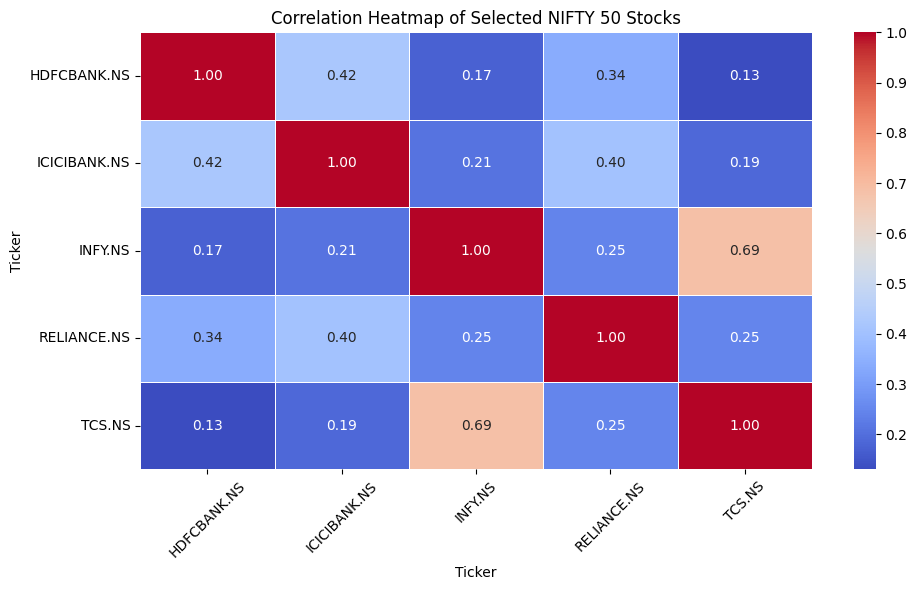

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",        # keeps numbers clean (0.68 instead of 0.687341)
    linewidths=0.5    # adds separation between boxes
)

plt.title("Correlation Heatmap of Selected NIFTY 50 Stocks")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 🔍 Interpretation

- Infosys and TCS showed the strongest correlation (**0.69**), indicating similar movements driven by common IT sector factors.
- HDFC Bank and ICICI Bank exhibited a moderate correlation (**0.42**), reflecting their exposure to the banking industry.
- HDFC Bank and TCS had the weakest correlation (**0.13**), suggesting stronger diversification benefits when combined.

### 💡 Key Insight

The heatmap highlights that stocks from the same sector tend to move more closely together, while stocks from different sectors show weaker relationships. This demonstrates the importance of diversification when constructing an investment portfolio.

## 🏆 Sharpe Ratio Analysis
The Sharpe Ratio is a widely used metric for evaluating risk-adjusted performance.
It measures how much return an investment generates for each unit of risk taken.

### Formula
Sharpe Ratio = Mean Daily Return / Standard Deviation of Returns
A higher Sharpe Ratio indicates better performance relative to the level of risk undertaken.

In [16]:
mean_daily_return = returns.mean()

risk = returns.std()

sharpe_ratio = mean_daily_return / risk

sharpe_ratio.sort_values(ascending=False)

Ticker
ICICIBANK.NS    0.070737
TCS.NS          0.052448
INFY.NS         0.044808
HDFCBANK.NS     0.024245
RELIANCE.NS     0.011023
dtype: float64

### 🔍 Interpretation

- ICICI Bank achieved the highest Sharpe Ratio (**0.0707**), indicating the strongest risk-adjusted performance.
- TCS (**0.0524**) and Infosys (**0.0448**) also delivered favorable returns relative to their risk levels.
- HDFC Bank recorded a moderate Sharpe Ratio (**0.0242**).
- Reliance had the lowest Sharpe Ratio (**0.0110**), suggesting lower returns for the risk undertaken.

### 💡 Key Insight

Based on the Sharpe Ratio, **ICICI Bank was the most efficient stock**, generating the highest return per unit of risk among the selected NIFTY 50 stocks.

# 📌 Conclusion

This project analyzed selected NIFTY 50 stocks using historical market data obtained through Yahoo Finance.

### Key Findings

- 🚀 ICICI Bank delivered the highest total return (**44.4%**).
- ⚠️ Infosys exhibited the highest volatility (**1.45%**).
- 🏆 ICICI Bank achieved the strongest risk-adjusted performance.
- 🔗 Infosys and TCS showed the strongest correlation (**0.69**).
- 📊 HDFC Bank and TCS offered the greatest diversification potential.

Overall, the analysis demonstrates how return, risk, Sharpe Ratio, and correlation metrics can be used together to make more informed investment decisions.